# Fundamentos de analítica 2 -Aprendizaje Automatico III (clase 2)

## Diego Fernando Agudelo - Daniel Felipe Osorio
## Universidad ICESI
## diegoagudelo30@gmail.com - dfosorio@icesi.edu.co

## **1. Carga de paquetes**

In [1]:
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from matplotlib import pyplot as plt # gráficos
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta

### **6. Tendencia Lineal**

In [2]:
data = pd.read_excel("datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


In [3]:
y = data["Ocupados"]
x = np.linspace(1,data.shape[0],data.shape[0])
X = sm.add_constant(x)
lin = sm.OLS(y,X)
lin_t = lin.fit()
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     4729.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):          1.02e-150
Time:                        20:53:00   Log-Likelihood:                -1559.9
No. Observations:                 222   AIC:                             3124.
Df Residuals:                     220   BIC:                             3131.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6962.4958     36.871    188.835      0.0

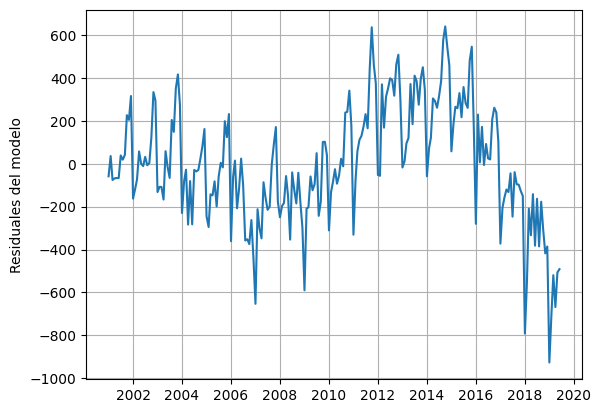

In [4]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

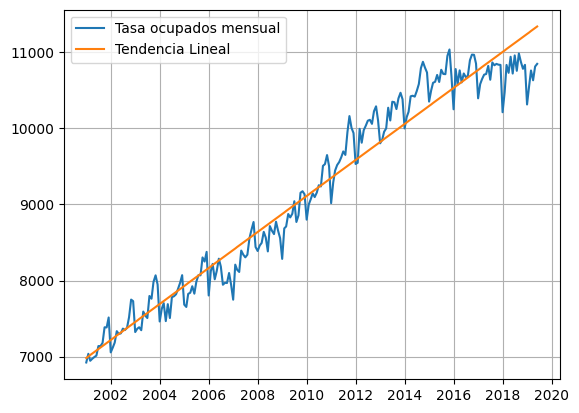

In [6]:
plt.plot(y,label="Tasa ocupados mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [7]:
h=15
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
X_for= sm.add_constant(x_for)


In [8]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

    Point_forecast      lower_95      upper_95
0     11359.208189  10814.820716  11903.595662
1     11378.924388  10834.471236  11923.377539
2     11398.640587  10854.121178  11943.159995
3     11418.356786  10873.770542  11962.943029
4     11438.072984  10893.419328  11982.726641
5     11457.789183  10913.067536  12002.510831
6     11477.505382  10932.715166  12022.295598
7     11497.221581  10952.362220  12042.080943
8     11516.937780  10972.008696  12061.866864
9     11536.653979  10991.654595  12081.653363
10    11556.370178  11011.299918  12101.440438
11    11576.086377  11030.944664  12121.228090
12    11595.802576  11050.588834  12141.016318
13    11615.518775  11070.232428  12160.805121
14    11635.234974  11089.875446  12180.594501


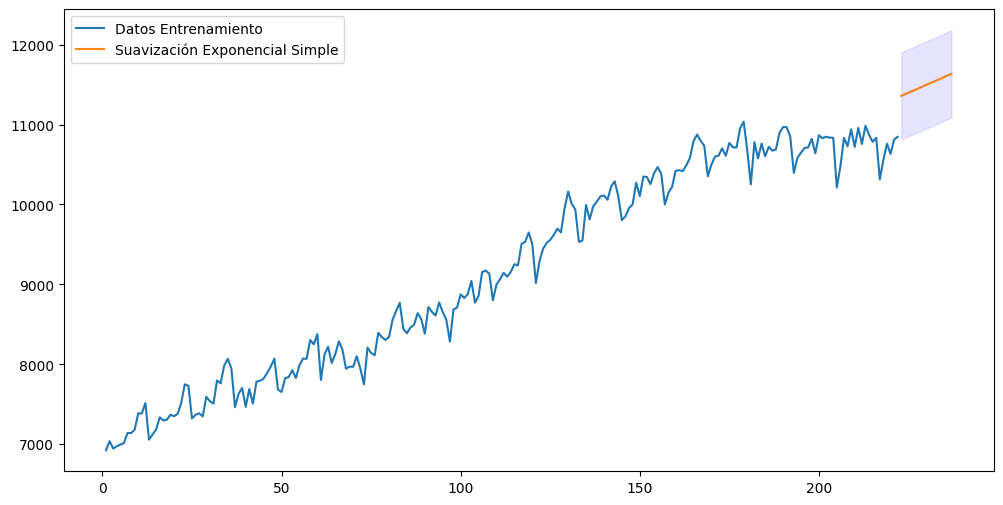

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()


### **7. Tendencia Cuadratica**

In [10]:
y = data["Ocupados"]
data["x"] = np.linspace(1,data.shape[0],data.shape[0])
data["x2"] = x**2
X = sm.add_constant(data[["x","x2"]])
pol = sm.OLS(y,X)
pol_2 = pol.fit()
print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2560.
Date:                Mon, 03 Nov 2025   Prob (F-statistic):          1.33e-152
Time:                        20:53:58   Log-Likelihood:                -1551.0
No. Observations:                 222   AIC:                             3108.
Df Residuals:                     219   BIC:                             3118.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6790.8804     53.552    126.810      0.0

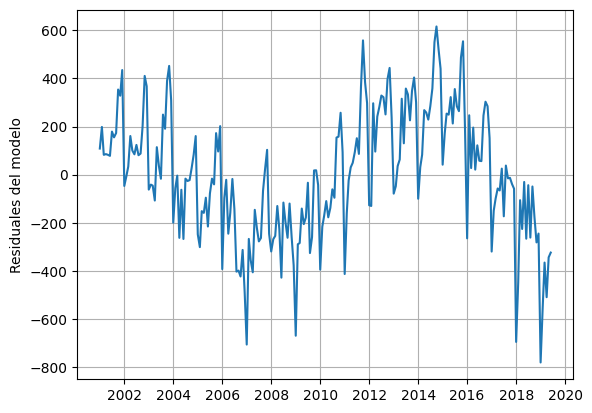

In [11]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

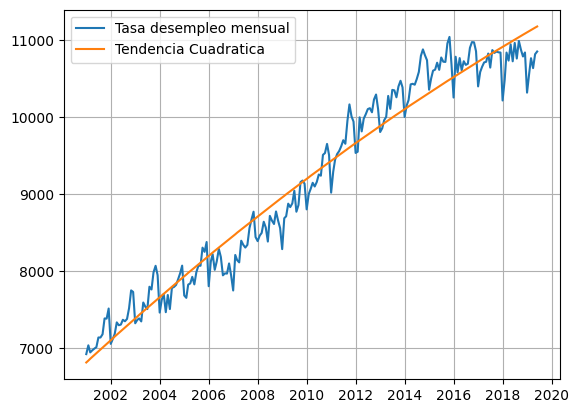

In [12]:
plt.plot(y,label="Tasa desempleo mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend()
plt.grid()
plt.show()

In [13]:
h=15
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [14]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

    Point_forecast      lower_95      upper_95
0     11187.592748  10657.511767  11717.673730
1     11202.691491  10672.226911  11733.156072
2     11217.749007  10686.889054  11748.608961
3     11232.765296  10701.497992  11764.032599
4     11247.740357  10716.053522  11779.427192
5     11262.674191  10730.555438  11794.792944
6     11277.566798  10745.003535  11810.130060
7     11292.418177  10759.397608  11825.438746
8     11307.228329  10773.737450  11840.719209
9     11321.997254  10788.022854  11855.971654
10    11336.724952  10802.253614  11871.196289
11    11351.411422  10816.429523  11886.393322
12    11366.056665  10830.550372  11901.562958
13    11380.660681  10844.615956  11916.705406
14    11395.223469  10858.626066  11931.820873


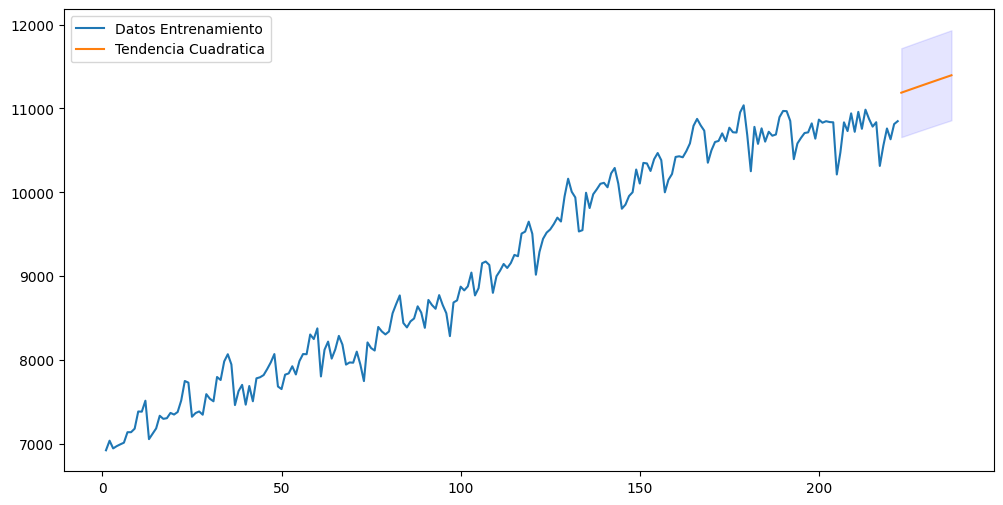

In [15]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cuadratica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **8. Estimación de la Estacionalidad**

In [16]:
month_dummies = pd.get_dummies(data.index.month,drop_first=True).set_index(data.index)
month_dummies

,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,
2001-01-01,False,False,False,False,False,False,False,False,False,False,False
2001-02-01,True,False,False,False,False,False,False,False,False,False,False
2001-03-01,False,True,False,False,False,False,False,False,False,False,False
2001-04-01,False,False,True,False,False,False,False,False,False,False,False
2001-05-01,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2019-02-01,True,False,False,False,False,False,False,False,False,False,False
2019-03-01,False,True,False,False,False,False,False,False,False,False,False
2019-04-01,False,False,True,False,False,False,False,False,False,False,False


In [17]:
y = data["TD_13ciudades"]
X = sm.add_constant(month_dummies)
sea = sm.OLS(y,X)
season = sea.fit()
print(season.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

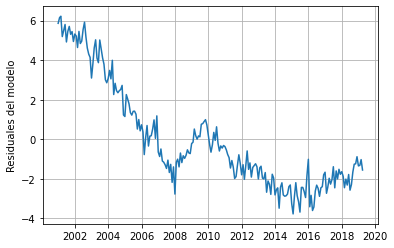

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

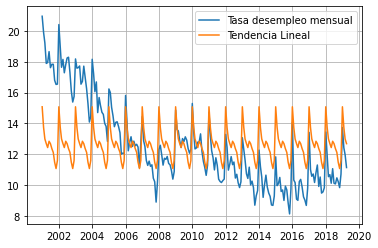

In [ ]:
plt.plot(y,label="Tasa desempleo mensual")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [ ]:
range_dates = pd.date_range(data.index[-1]+ relativedelta(months=1), periods=12,freq='MS')

x_for = pd.get_dummies(range_dates.month,drop_first=True)
X_for= sm.add_constant(x_for)

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



In [ ]:
dt = season.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast  lower_95   upper_95
2019-05-01       12.439530  6.991798  17.887262
2019-06-01       12.847900  7.400168  18.295632
2019-07-01       12.692178  7.244446  18.139910
2019-08-01       12.370225  6.922493  17.817957
2019-09-01       12.127269  6.679537  17.575001
2019-10-01       11.486721  6.038989  16.934453
2019-11-01       11.080408  5.632676  16.528140
2019-12-01       11.602981  6.155248  17.050713
2020-01-01       15.080853  9.640671  20.521034
2020-02-01       13.741252  8.301070  19.181433
2020-03-01       12.998513  7.558332  18.438695
2020-04-01       12.693503  7.253322  18.133685


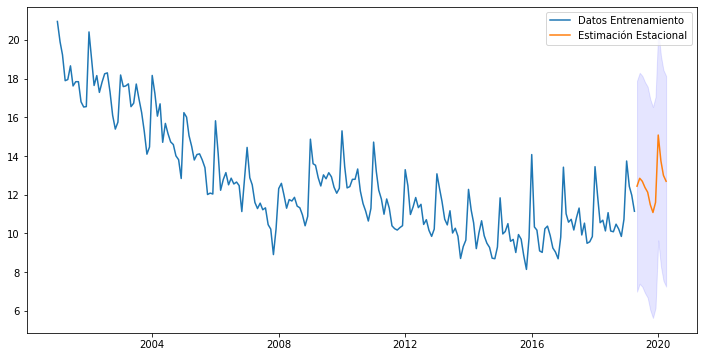

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **9. Tendencia + Estacionalidad**

In [ ]:
y = data["TD_13ciudades"]
data["x"] = np.linspace(1,data.shape[0],data.shape[0])
data["x2"] = x**2

month_dummies = pd.get_dummies(data.index.month,drop_first=True).set_index(data.index)
X = sm.add_constant( pd.concat([data[["x","x2"]],month_dummies],axis=1) )

season_pol2 = sm.OLS(y,X)
season_pol_2 = season_pol2.fit()
print(season_pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:          TD_13ciudades   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     174.2
Date:                Thu, 02 Feb 2023   Prob (F-statistic):          2.19e-103
Time:                        14:28:37   Log-Likelihood:                -266.22
No. Observations:                 220   AIC:                             560.4
Df Residuals:                     206   BIC:                             607.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.2179      0.249     85.365      0.0

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



In [ ]:
X

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2001-01-01,1.0,1.0,1.0,0,0,0,0,0,0,0,0,0,0,0
2001-02-01,1.0,2.0,4.0,1,0,0,0,0,0,0,0,0,0,0
2001-03-01,1.0,3.0,9.0,0,1,0,0,0,0,0,0,0,0,0
2001-04-01,1.0,4.0,16.0,0,0,1,0,0,0,0,0,0,0,0
2001-05-01,1.0,5.0,25.0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,1.0,216.0,46656.0,0,0,0,0,0,0,0,0,0,0,1
2019-01-01,1.0,217.0,47089.0,0,0,0,0,0,0,0,0,0,0,0
2019-02-01,1.0,218.0,47524.0,1,0,0,0,0,0,0,0,0,0,0


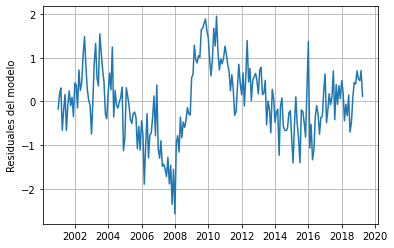

In [ ]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol_2.resid)
plt.grid()

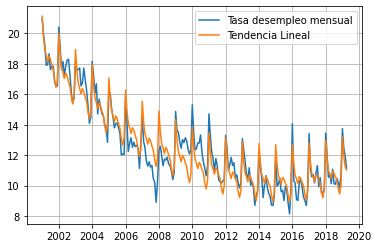

In [ ]:
plt.plot(y,label="Tasa desempleo mensual")
plt.plot(season_pol_2.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [ ]:
h=12
x_for= np.linspace((data.shape[0]+1),(data.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**2),axis=1),columns=["x","x2"] )

range_dates = pd.date_range(data.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True)

X_for= sm.add_constant(pd.concat([x_for_all,x_for_dummies],axis=1))
X_for

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning:

In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only



,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
0,1.0,221.0,48841.0,0,0,0,1,0,0,0,0,0,0,0
1,1.0,222.0,49284.0,0,0,0,0,1,0,0,0,0,0,0
2,1.0,223.0,49729.0,0,0,0,0,0,1,0,0,0,0,0
3,1.0,224.0,50176.0,0,0,0,0,0,0,1,0,0,0,0
4,1.0,225.0,50625.0,0,0,0,0,0,0,0,1,0,0,0
5,1.0,226.0,51076.0,0,0,0,0,0,0,0,0,1,0,0
6,1.0,227.0,51529.0,0,0,0,0,0,0,0,0,0,1,0
7,1.0,228.0,51984.0,0,0,0,0,0,0,0,0,0,0,1
8,1.0,229.0,52441.0,0,0,0,0,0,0,0,0,0,0,0
9,1.0,230.0,52900.0,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
dt = season_pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast   lower_95   upper_95
2019-05-01       10.745957   9.016194  12.475720
2019-06-01       11.219334   9.488506  12.950162
2019-07-01       11.128620   9.396699  12.860541
2019-08-01       10.871674   9.138631  12.604716
2019-09-01       10.693725   8.959533  12.427916
2019-10-01       10.118184   8.382815  11.853553
2019-11-01        9.776879   8.040305  11.513453
2019-12-01       10.364458   8.626652  12.102265
2020-01-01       13.571859  11.836180  15.307538
2020-02-01       12.300687  10.563705  14.037669
2020-03-01       11.626377   9.888061  13.364693
2020-04-01       11.389796   9.650115  13.129477


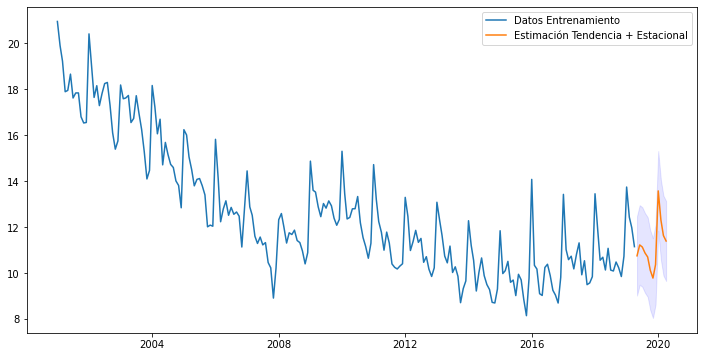

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### **10. Comparación de modelos**

Para realizar la comparación de los modelos se debe usar una metrica de desempeño, en la clase anterior usamos el RMSE, la comparación se debe hacer fuera de muestra.

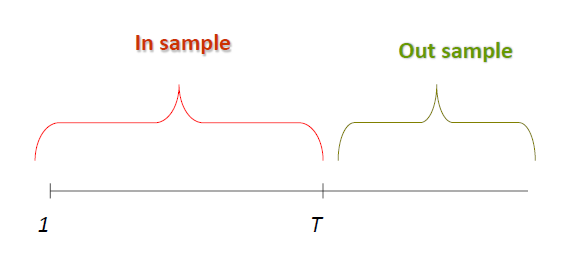

### **11. Evaluación de los supuestos de los residuales**

Para poder hacer uso del modelo y los pronósticos se deben cumplir los supuestos del Teorema de Gauss-Markov sobre los residuales de un modelo de regresión múltiple.

- Probar **Autocorrelación** en los **residuales** con las pruebas Box-Pierce y Ljung-Box para los diferentes rezagos.

- Probar **Homoscedasticidad/Heteroscedasticidad** sobre los residuales, una aproximación para determinar si existe un comportamiento GARCH o ARCH es emplear la prueba de Ljung-Box sobre la serie (sin media) al cuadrado. En este caso al ser residuales de una regresión las series ya tienen media cero.

- Probar **Normalidad** sobre los residuales con las pruebas Jarque Bera y Shapiro-Wilk, adicionalmente se pueden realizar las graficas para ver el comportamiento de manera visual.

### **12. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses empleando los métodos vistos en la clase. Compare
los resultados con el mejor modelo encontrado en el ejercicio anterior.

Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.